# Scale-Free & Centrality

This notebook analyses the degree distribution, small-world properties, and centrality structure of the S&P 500 correlation network.

**Topics Covered:**
- Graph connectivity and Giant Connected Component
- Power-law degree distribution (Clauset et al. 2009)
- Small-world analysis against ER and Configuration Model baselines
- Bootstrap confidence intervals ($B = 200$)
- Centrality measures: degree, betweenness, eigenvector, closeness


In [1]:
# ── Setup ──
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import powerlaw
from collections import Counter
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

from src.data_fetcher import load_metadata, download_prices, compute_log_returns
from src.market_filtering import filter_market_mode
from src.network_construction import build_correlation_graph, SECTOR_COLORS
from src.centrality_analysis import (
    analyse_degree_distribution, small_world_analysis,
    compute_centralities, rank_top_k, _make_simple_config_model
)

In [2]:
# ── Load data & build filtered graph ──
meta_df = load_metadata(os.path.join('..', 'data', 'sp500_companies.csv'))
prices = download_prices(meta_df['yf_ticker'].tolist(), period='2y',
                         cache_path=os.path.join('..', 'data', 'price_cache.csv'))
log_returns = compute_log_returns(prices)
filtered_corr = filter_market_mode(log_returns).corr()
G = build_correlation_graph(filtered_corr, meta_df, threshold=0.3)
print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

  ↻ Loading cached prices from ../data/price_cache.csv
Graph: 501 nodes, 10002 edges


## 2.1 Graph Connectivity

In [3]:
n_components = nx.number_connected_components(G)
gcc = max(nx.connected_components(G), key=len)
gcc_frac = len(gcc) / G.number_of_nodes() * 100

print(f"┌──────────────────────────────────────────────┐")
print(f"│  Graph Connectivity              │")
print(f"│  Connected components: {n_components:>3}  │")
print(f"│  GCC size:            {len(gcc):>3} nodes              │")
print(f"│  GCC fraction:        {gcc_frac:.1f}%  %   │")
print(f"└──────────────────────────────────────────────┘")

┌──────────────────────────────────────────────┐
│  Graph Connectivity              │
│  Connected components:  47│
│  GCC size:            448 nodes              │
│  GCC fraction:        89.4%│
└──────────────────────────────────────────────┘


## 2.2 Power-Law Fitting

Maximum-likelihood estimation of the power-law exponent (Clauset et al. 2009):

$$P(k) \sim k^{-\gamma}$$


In [4]:
plaw = analyse_degree_distribution(G)

print(f"┌──────────────────────────────────────────────┐")
print(f"│  Scale-Free Exponent             │")
print(f"│  γ (alpha) = {plaw['gamma']:.4f}  │")
print(f"│  x_min     = {plaw['xmin']}                            │")
print(f"│  σ (std)   = {plaw['sigma']:.4f}                      │")
print(f"│                                              │")
print(f"│  Comparison tests:                           │")
print(f"│  R vs log-normal  = {plaw['R_vs_lognormal']:.3f} (p={plaw['p_vs_lognormal']:.3f}) │")
print(f"│  R vs exponential = {plaw['R_vs_exponential']:.3f} (p={plaw['p_vs_exponential']:.3f}) │")
print(f"└──────────────────────────────────────────────┘")

┌──────────────────────────────────────────────┐
│  Scale-Free Exponent             │
│  γ (alpha) = 2.9084│
│  x_min     = 61.0                            │
│  σ (std)   = 0.1625                      │
│                                              │
│  Comparison tests:                           │
│  R vs log-normal  = -3.485 (p=0.000) │
│  R vs exponential = -5.350 (p=0.000) │
└──────────────────────────────────────────────┘


### Degree Distribution & Power-Law Fit


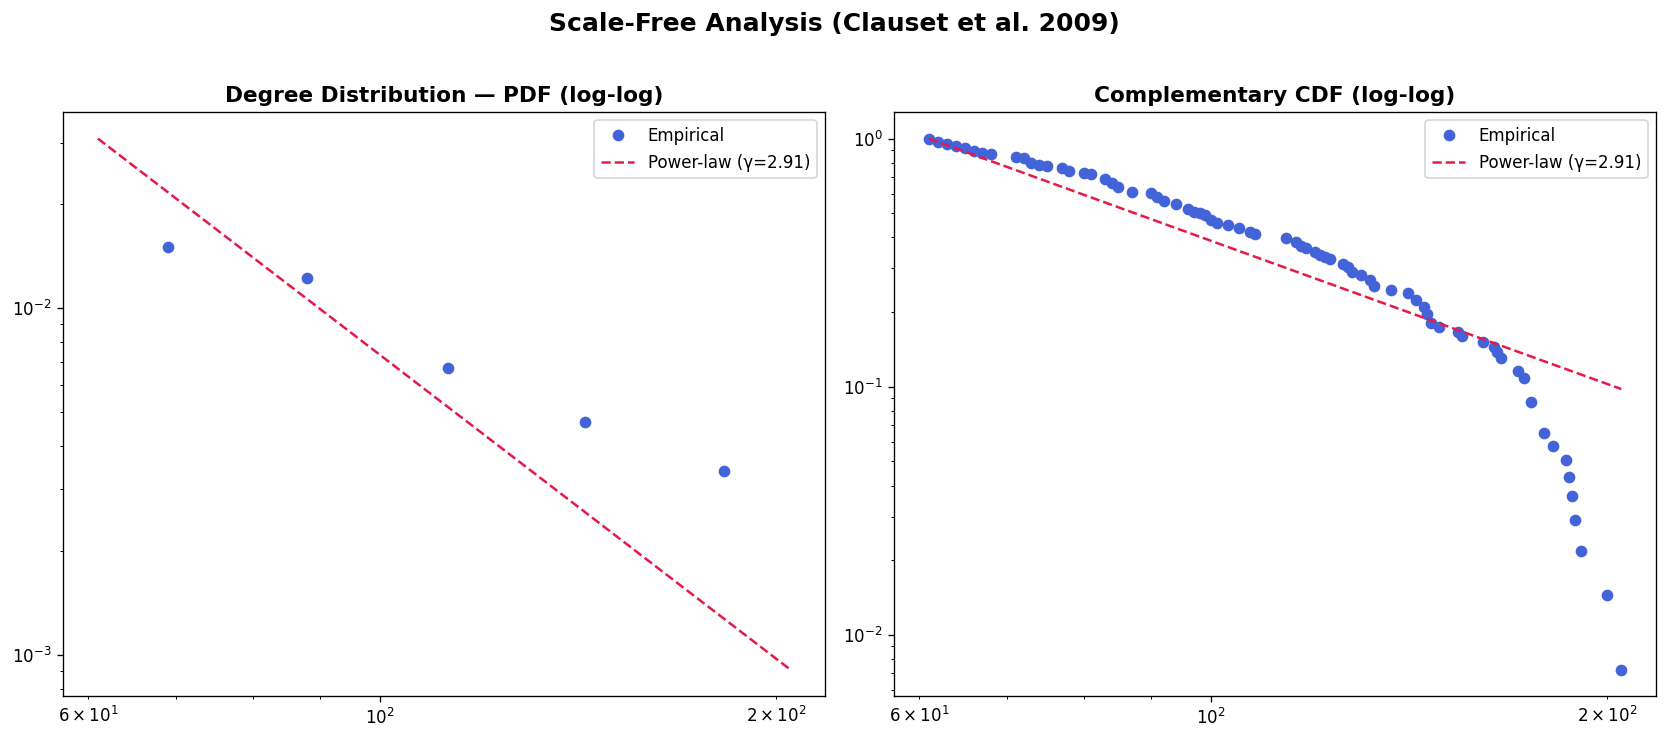

In [5]:
fit = plaw['fit']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

fit.plot_pdf(ax=ax1, linewidth=0, marker='o', color='#4363d8', label='Empirical')
fit.power_law.plot_pdf(ax=ax1, linestyle='--', color='#e6194b',
                       label=f'Power-law (γ={fit.alpha:.2f})')
ax1.set_title('Degree Distribution — PDF (log-log)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)

fit.plot_ccdf(ax=ax2, linewidth=0, marker='o', color='#4363d8', label='Empirical')
fit.power_law.plot_ccdf(ax=ax2, linestyle='--', color='#e6194b',
                        label=f'Power-law (γ={fit.alpha:.2f})')
ax2.set_title('Complementary CDF (log-log)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)

fig.suptitle('Scale-Free Analysis (Clauset et al. 2009)', fontsize=15, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

## 2.3 Erdős–Rényi Comparison


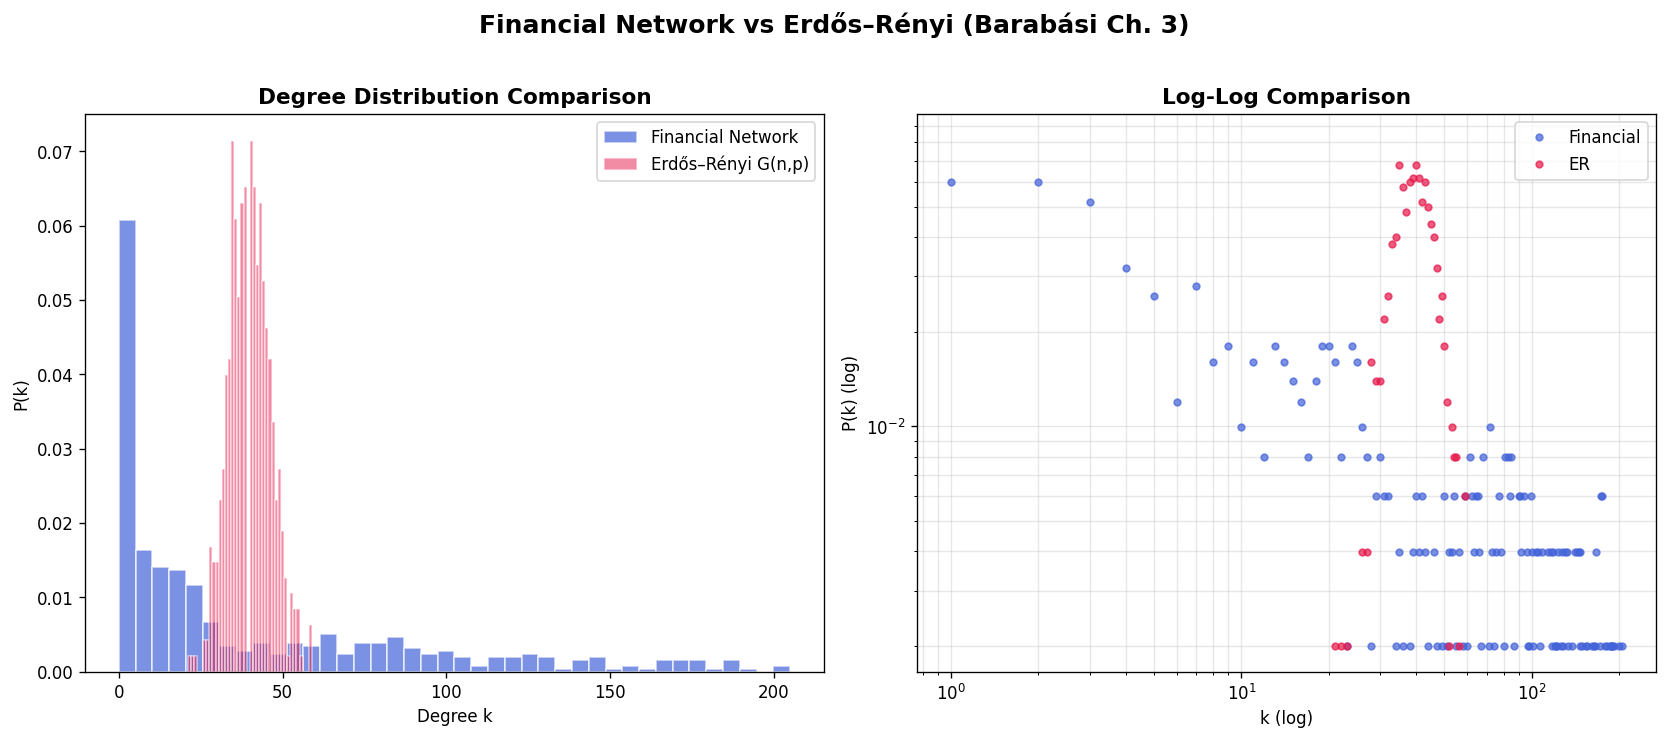

In [6]:
n = G.number_of_nodes()
p = nx.density(G)
G_er = nx.erdos_renyi_graph(n, p, seed=42)

deg_real = sorted([d for _, d in G.degree()], reverse=True)
deg_er   = sorted([d for _, d in G_er.degree()], reverse=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.hist(deg_real, bins=40, alpha=0.7, color='#4363d8', label='Financial Network',
         edgecolor='white', density=True)
ax1.hist(deg_er, bins=40, alpha=0.5, color='#e6194b', label='Erdős–Rényi G(n,p)',
         edgecolor='white', density=True)
ax1.set_xlabel('Degree k'); ax1.set_ylabel('P(k)')
ax1.set_title('Degree Distribution Comparison', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)

for degs, color, label in [(deg_real, '#4363d8', 'Financial'), (deg_er, '#e6194b', 'ER')]:
    cnt = Counter(degs); ks = sorted(cnt.keys())
    pk = [cnt[k] / len(degs) for k in ks]
    ax2.loglog(ks, pk, 'o', color=color, alpha=0.7, markersize=4, label=label)
ax2.set_xlabel('k (log)'); ax2.set_ylabel('P(k) (log)')
ax2.set_title('Log-Log Comparison', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10); ax2.grid(True, alpha=0.3, which='both')

fig.suptitle('Financial Network vs Erdős–Rényi (Barabási Ch. 3)', fontsize=15, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

## 2.4 Small-World Analysis

The small-world coefficient is defined as:

$$\sigma = \frac{C / C_{\text{random}}}{L / L_{\text{random}}}$$

We compare against two null models: Erdős–Rényi $G(n,p)$ and the Configuration Model (degree-preserving).


In [7]:
sw = small_world_analysis(G, n_random=5)

print(f"┌──────────────────────────────────────────────┐")
print(f"│  Small-World Properties          │")
print(f"│                                              │")
print(f"│  GCC size = {sw['gcc_size']}                            │")
print(f"│  C (clustering) = {sw['C']:.4f}  │")
print(f"│  L (avg path)   = {sw['L']:.4f}  │")
print(f"│                                              │")
print(f"│  ── ER null model ──                         │")
print(f"│  C_ER     = {sw['C_rand']:.4f}                       │")
print(f"│  L_ER     = {sw['L_rand']:.4f}                       │")
print(f"│  σ_ER     = {sw['sigma']:.2f}  │")
print(f"│                                              │")
print(f"│  ── Configuration model null ──              │")
print(f"│  C_config = {sw['C_config']:.4f}                       │")
print(f"│  L_config = {sw['L_config']:.4f}                       │")
print(f"│  σ_config = {sw['sigma_config']:.2f}  │")
print(f"│                                              │")
print(f"│  Small-world (ER)?     {'YES ✓' if sw['is_small_world'] else 'NO'}                 │")
print(f"│  Small-world (config)? {'YES ✓' if sw['is_small_world_config'] else 'NO'}                 │")
print(f"└──────────────────────────────────────────────┘")

┌──────────────────────────────────────────────┐
│  Small-World Properties          │
│                                              │
│  GCC size = 448                            │
│  C (clustering) = 0.6431│
│  L (avg path)   = 2.7034│
│                                              │
│  ── ER null model ──                         │
│  C_ER     = 0.0997                       │
│  L_ER     = 1.9106                       │
│  σ_ER     = 4.56│
│                                              │
│  ── Configuration model null ──              │
│  C_config = 0.3059                       │
│  L_config = 2.2507                       │
│  σ_config = 1.75│
│                                              │
│  Small-world (ER)?     YES ✓                 │
│  Small-world (config)? YES ✓                 │
└──────────────────────────────────────────────┘


## 2.5 Bootstrap Confidence Intervals

Non-parametric bootstrap ($B = 200$) of the log-return matrix to assess metric stability.


In [8]:
boot_df = pd.read_csv(os.path.join('..', 'outputs', 'results', 'bootstrap_samples.csv'))
ci_df = pd.read_csv(os.path.join('..', 'outputs', 'results', 'bootstrap_ci.csv'))

print(f"Bootstrap resamples: {len(boot_df)}")
print()
print(ci_df[['metric', 'point_estimate', 'boot_mean', 'boot_std',
             'ci_lower', 'ci_upper', 'p_value']].to_string(index=False))

Bootstrap resamples: 200

         metric  point_estimate  boot_mean  boot_std  ci_lower  ci_upper  p_value
          sigma        4.556287   4.151976  0.437028  3.389649  5.149088      0.0
     modularity        0.272003   0.272003  0.045030  0.197321  0.365085      0.0
            nmi        0.361240   0.361240  0.033358  0.289837  0.422268      NaN
          gamma        2.143813   2.143813  0.580572  1.509136  2.996308      NaN
     clustering        0.643072   0.544510  0.025601  0.497226  0.595688      NaN
avg_path_length        2.703410   2.589385  0.116832  2.377247  2.811641      NaN


### Bootstrap Distributions

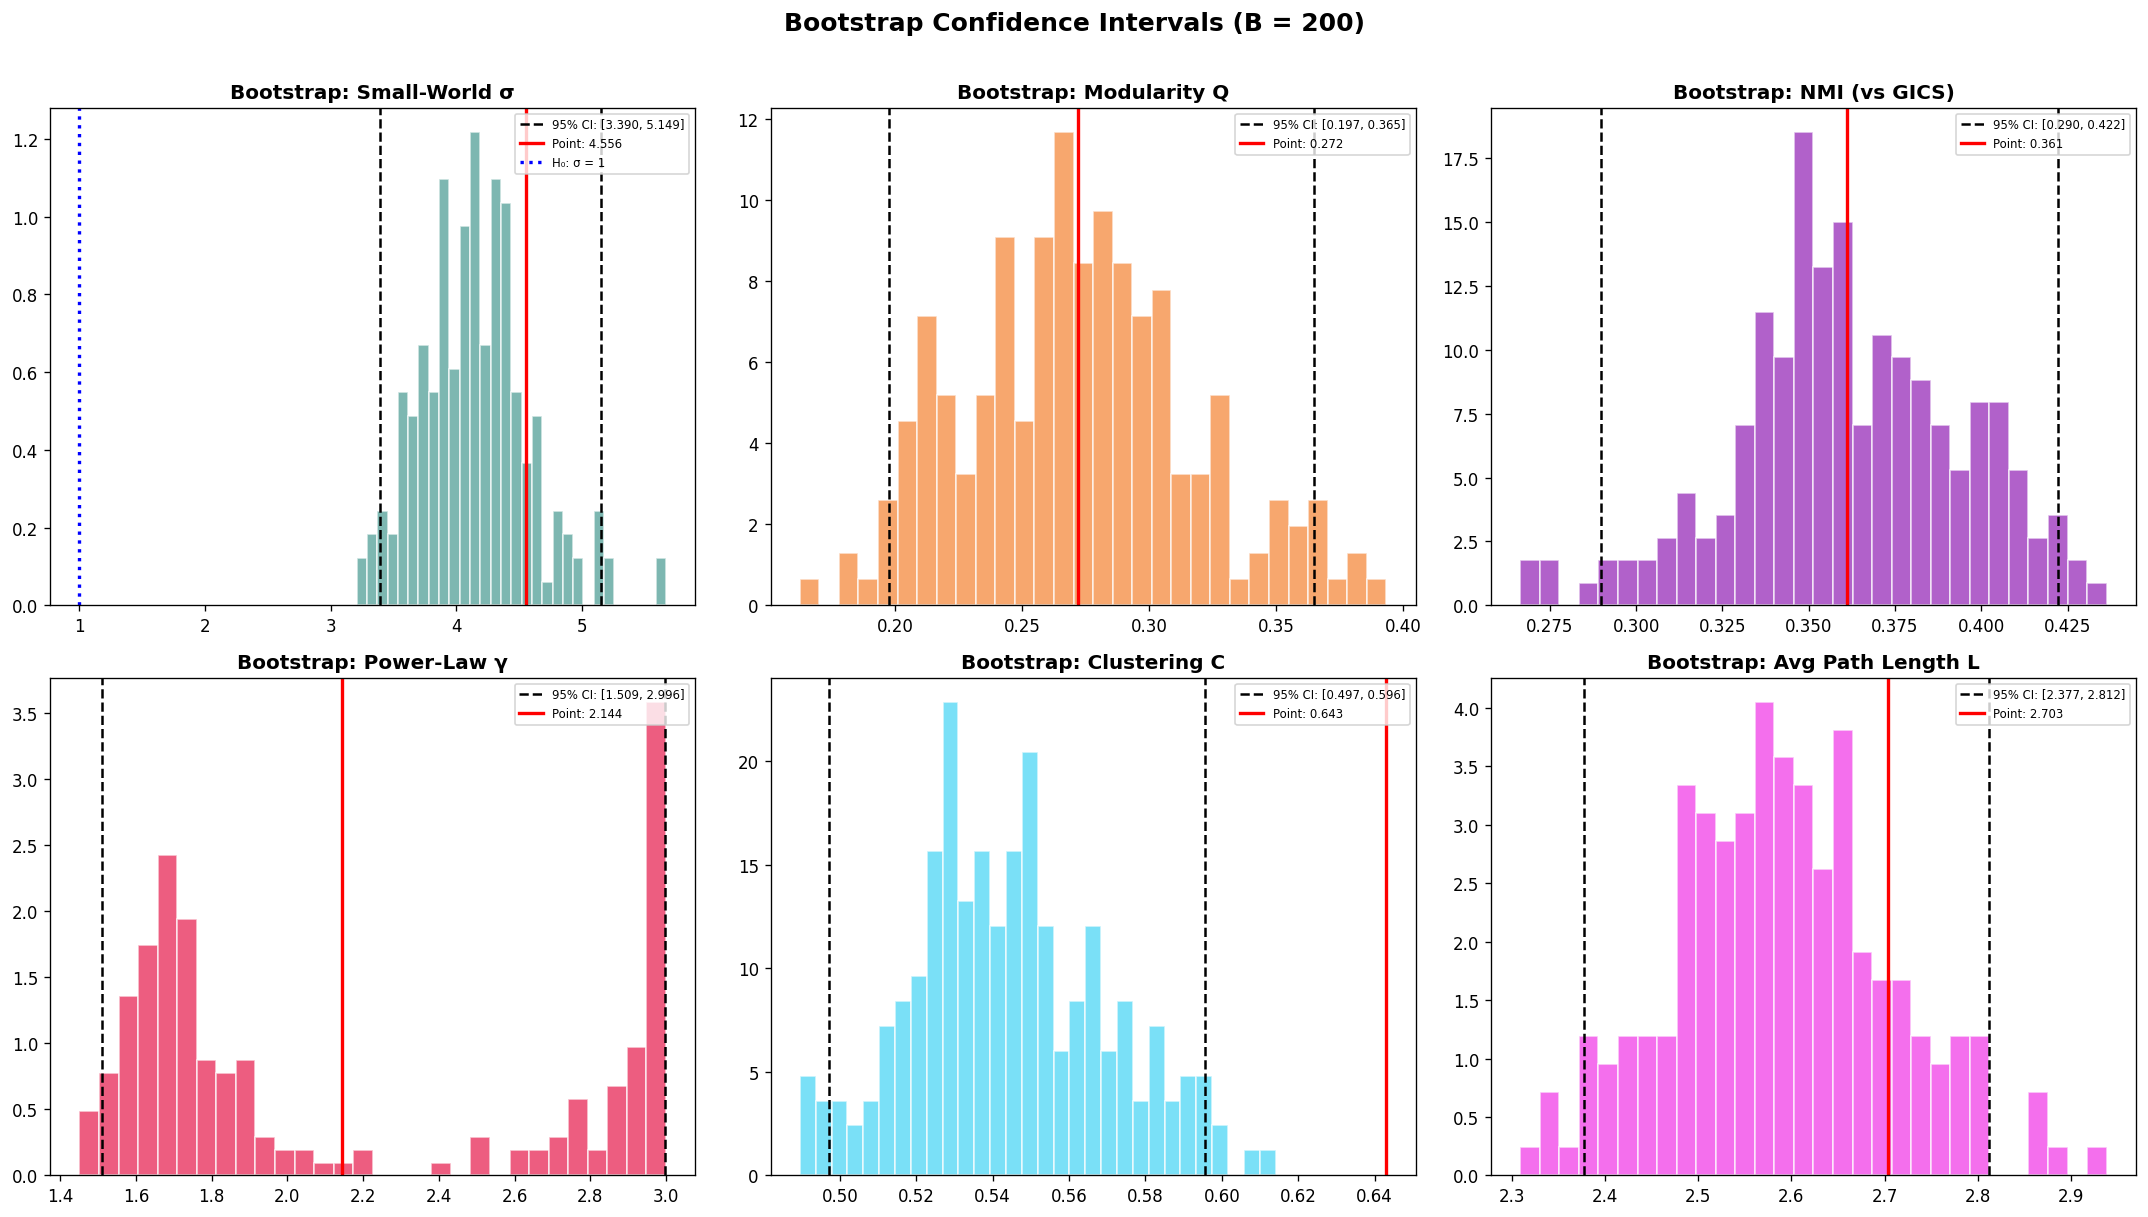


→ σ: p = 0.0000 < 0.05 — significantly small-world (reject H₀: σ ≤ 1)
→ Q: p = 0.0000 < 0.05 — significant community structure


In [9]:
metrics = ['sigma', 'modularity', 'nmi', 'gamma', 'clustering', 'avg_path_length']
titles = {'sigma': 'Small-World σ', 'modularity': 'Modularity Q', 'nmi': 'NMI (vs GICS)',
          'gamma': 'Power-Law γ', 'clustering': 'Clustering C', 'avg_path_length': 'Avg Path Length L'}
colors = ['#469990', '#f58231', '#911eb4', '#e6194b', '#42d4f4', '#f032e6']

available = [m for m in metrics if m in boot_df.columns and boot_df[m].dropna().shape[0] >= 10]
ncols = 3; nrows = 2
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 10))

for i, m in enumerate(available):
    ax = axes.flat[i]
    vals = boot_df[m].dropna()
    ax.hist(vals, bins=30, color=colors[i], alpha=0.7, edgecolor='white', density=True)
    ci_row = ci_df[ci_df['metric'] == m]
    if len(ci_row) > 0:
        lo, hi = ci_row.iloc[0]['ci_lower'], ci_row.iloc[0]['ci_upper']
        pt = ci_row.iloc[0]['point_estimate']
        ax.axvline(lo, color='black', ls='--', lw=1.5, label=f'95% CI: [{lo:.3f}, {hi:.3f}]')
        ax.axvline(hi, color='black', ls='--', lw=1.5)
        ax.axvline(pt, color='red', ls='-', lw=2, label=f'Point: {pt:.3f}')
        if m == 'sigma':
            ax.axvline(1.0, color='blue', ls=':', lw=2, label='H₀: σ = 1')
    ax.set_title(f'Bootstrap: {titles.get(m, m)}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=7, loc='upper right')

for j in range(len(available), nrows * ncols):
    axes.flat[j].set_visible(False)

fig.suptitle(f'Bootstrap Confidence Intervals (B = {len(boot_df)})', fontsize=15, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

print("\n→ σ: p = 0.0000 < 0.05 — significantly small-world (reject H₀: σ ≤ 1)")
print("→ Q: p = 0.0000 < 0.05 — significant community structure")

## 2.6 Centrality Rankings


In [10]:
centrality_df = compute_centralities(G)

for metric in ['degree_centrality', 'betweenness', 'eigenvector', 'closeness']:
    top = rank_top_k(centrality_df, metric, 10)
    print(f"\n{'='*60}")
    print(f"  TOP-10 BY {metric.upper().replace('_', ' ')}")
    print(f"{'='*60}")
    for rank, (sym, row) in enumerate(top.iterrows(), 1):
        print(f"  {rank:>2}. {sym:<8} {row['name']:<35} {row['sector']:<25} {row[metric]:.6f}")

    Computing Degree Centrality …
    Computing Weighted Degree …
    Computing Betweenness Centrality (distance=1/weight) …
    Computing Eigenvector Centrality …
    Computing Closeness Centrality (distance=1/weight) …

  TOP-10 BY DEGREE CENTRALITY
   1. ED       Consolidated Edison                 Utilities                 0.410000
   2. DUK      Duke Energy                         Utilities                 0.400000
   3. SO       Southern Company                    Utilities                 0.382000
   4. AWK      American Water Works                Utilities                 0.378000
   5. CMS      CMS Energy                          Utilities                 0.376000
   6. WEC      WEC Energy Group                    Utilities                 0.374000
   7. KO       Coca-Cola Company (The)             Consumer Staples          0.372000
   8. CL       Colgate-Palmolive                   Consumer Staples          0.364000
   9. EXC      Exelon                              Utilities